# Implementacão - Dask

## Detalhes

1. Gestão de Dados
- Dask não herda variáveis globais via Copy-on-Write (fork) da mesma forma transparente que o *multiprocessing*.
- Os daods precisam ser movidos epxlicitamente
- É necessário utilizar *client.scatter* para enviar as matrizes aos workers de forma eficiente.
- Usando client.scatter, os dadossão enviados uma única vez para a memória distribuída do cluster, e os workers acessam essa referência. Isso adiciona um overhead de comunicação que não existia no script original.

2. Scheduler e Workers
- O Dask sobe um Scheduler (agendador) e Workers (trabalhadores).
- Os workers são processos "daemon" de longa duração que ficam aguardando instruções via protocolo TCP (mesmo localmente).
- Eles não "herdam" o estado do script principal da mesma forma simples.
- O Dask serializa (empacota com pickle ou cloudpickle) **a função e os dados** e os envia via rede/socket para o worker.

3. Vantagens de utilizar Dask
- Multi-Node: Dask consegue executar programas utilizando usando múltiplas CPUs (múltiplos nodos) de diferentes computadores da rede. O multiprocessing não faz isso; o Dask faz transparentemente (basta apontar o IP do scheduler).
- Matrizes Gigantes (Out-of-Core): Se MATRIX_SIZE fosse 50.000 e não coubesse na RAM o comando *dask.array* quebraria a matriz em pedaços menores e carregaria do disco sob demanda.

## Dashboard

- O Dask oferece um dashboard web (porta 8787) para visualizar o uso de CPU/Memória em tempo real.
- Dashboard: http://127.0.0.1:8787
- Dependência:

```bash
pip install "bokeh!=3.0.*,>=2.4.2" --proxy "http://proxy.tjrs.gov.br:8080"
```

## Funcinamento do script

1. **O Cluster Dask** (*LocalCluster* e *Client*)

```python
with LocalCluster(n_workers=len(cores), threads_per_worker=1, processes=True...) as cluster:
    with Client(cluster) as client:
```        

- **LocalCluster**: Cria um "mini datacenter" dentro do seu computador.
- **processes=True**: Em Python, threads normais não rodam em paralelo real (devido ao GIL). Ao usar processos, cada worker é um programa Python independente com sua própria memória.
- **threads_per_worker=1**: Reforça que cada worker é puramente single-threaded. Isso é ideal para tarefas CPU-bound (matemática pesada), pois evita a troca de contexto desnecessária.

2. Compartilhamento de dados com *client.scatter*

```python
A_future = client.scatter(A_host, broadcast=True)
B_future = client.scatter(B_host, broadcast=True)
``` 

- Em bibliotecas comuns (multiprocessing), ao enviar dados para um processo filho, o Python precisa "serializar" (pickle) e copiar os dados. Se a matriz possui 1GB e existem 8 workers, são copiados 8GB de dados, saturando a RAM.
- Ao utilziar *scatter* a matriz é enviada para a memória dos workers antes da computação começar (memória compartilhada).
- É retornado um *Future* (uma espécie de "ticket" ou ponteiro).
- Os workers acessam os dados pelo "ticket", sem necessidade de copiar a matriz inteira novamente. Ao utilizar *broadcast=True*, todos os workers já têm uma cópia da matriz B e do pedaço de A prontos em suas memórias locais.

## Versão do Python

- O Python 3.12 deve ser executado para o script Dask.

1. Verificar com *pyenv* as versões

```bash
pyenv versions
```

2. Para instalar o Python 3.12 no *pyenv*. Ao selecionar a versão 3.12, acabou instalado o Python 3.12.12

```bash
pyenv install 3.12
```

3. Versão global: selecionar a versão 3.12.12
- Isto define a versão padrão para todos os shells e diretórios, a menos que uma versão local ou shell a substitua.

```bash
pyenv global 3.12.12
```

4. Nível Shell (Temporário)
- Isto define a versão apenas para a sessão atual do terminal. É temporário e se reverte ao fechar o terminal.


```bash
pyenv shell 3.12.12
```








## Execução do Jupyer Notebook

```python
OPENBLAS_NUM_THREADS=1 jupyter notebook
```

## Confirmação de versão do Python em uso

In [5]:
import sys
print(sys.version_info)

sys.version_info(major=3, minor=12, micro=3, releaselevel='final', serial=0)


In [6]:
import psutil
import getpass
import os
import sys
import time
import numpy as np
import pandas as pd
from datetime import datetime
from dask.distributed import Client, LocalCluster

# --------------------------------------
# CONFIGURATION
MATRIX_SIZE = 6000
CPU_SETS = {   
    "8P_HT_OFF": [0, 2, 4, 6, 8, 10, 12, 14], # p-cores (8 cores, 1 thread per core)
    "4P_HT_ON": [0, 1, 2, 3, 4, 5, 6, 7], # p-cores (4 cores, 2 threads per core)
    "4P_4E_HT_OFF": [0, 2, 4, 6, 16, 17, 18, 19], # p-cores e e-cores (4 cores p-core, 4 cores e-core)
    "8E": [16, 17, 18, 19, 20, 21, 22, 23] # e-cores (8 cores, 1 thread per core)
}
NUM_RUNS = 10
GOVERNOR = "performance"
IDLE_TIME = 15

# --------------------------------------
# Helper Functions (Governor & Safety)
def safety_check(cpu_ids):
    if MATRIX_SIZE % len(cpu_ids) != 0:
        print(f"Error: MATRIX_SIZE ({MATRIX_SIZE}) not divisible by workers ({len(cpu_ids)}).")
        sys.exit(1)

def set_governor(governor: str):
    """
    Altera o CPU governor de todos os núcleos para o valor especificado.

    Parâmetros:
        governor (str): nome do governor (ex.: "performance", "powersave", "schedutil").
    """
    password = getpass.getpass("Sudo password: ")

    # Interpolamos o valor do parâmetro governor dirTempetamente no comando bash
    bash_command = f"""
    for cpu_file in $(ls -v /sys/devices/system/cpu/cpu*/cpufreq/scaling_governor); do
        cpu_name=$(basename $(dirname $(dirname $cpu_file)))
        
        echo "{governor}" | sudo tee $cpu_file > /dev/null
        
        current_gov=$(cat $cpu_file)
        #echo "$cpu_name: $current_gov"
    done
    """

    # Usa sudo -S para aceitar senha via stdin
    command = f'echo "{password}" | sudo -S bash -c \'{bash_command}\''
    os.system(command)   

def get_governor(cpu_id):
    path = f"/sys/devices/system/cpu/cpu{cpu_id}/cpufreq/scaling_governor"
    try:
        with open(path) as f: return f.read().strip()
    except FileNotFoundError: return "N/A"

# --------------------------------------
# Worker Task Adaptada para Dask
def worker_task_dask(args):
    """
    Recebe os dados explicitamente (A e B são referências scatter do Dask).
    """
    row_index, chunk_size, cpu_ids, A_matrix, B_matrix = args
    
    # Identificação rudimentar do worker baseada no chunk (assumindo ordem)
    # Em Dask, isso é menos determinístico, mas funciona se tasks == workers
    worker_id = row_index // chunk_size 
    target_cpu = cpu_ids[worker_id % len(cpu_ids)]

    # Define afinidade
    p = psutil.Process(os.getpid())
    p.cpu_affinity([target_cpu])
    
    # Fatia a matriz A localmente
    start_row = row_index
    end_row = row_index + chunk_size
    A_chunk = A_matrix[start_row:end_row, :]

    # -------------------------------------------------------------------------
    # LER A AFINIDADE REGISTRADA PELO SISTEMA
    # p.cpu_affinity() sem argumentos retorna a lista de cores restritos
    
    # O Dask worker é um processo, então esperamos que a lista tenha apenas um elemento
    #registered_cores = p.cpu_affinity() 
    
    # Usamos [0] para obter o ID do núcleo
    #system_core = registered_cores[0] if registered_cores else "N/A"
    
    #print(f"Worker PID: {os.getpid()} | Core Definido (target_cpu): {target_cpu} | Core REGISTRADO pelo Sistema: {system_core}")
    # -------------------------------------------------------------------------
    
    # Cálculo
    return np.dot(A_chunk, B_matrix)

# --------------------------------------
# Main Execution
if __name__ == "__main__":
    # print("Passo 1: Configurar governor")
    set_governor(GOVERNOR) # Descomente se tiver permissões sudo

    results = []
    print("Passo 2: Execuções com Dask")

    # Gerar dados
    A_host = np.random.rand(MATRIX_SIZE, MATRIX_SIZE).astype(np.float64)
    B_host = np.random.rand(MATRIX_SIZE, MATRIX_SIZE).astype(np.float64)
    
    for run in range(1, NUM_RUNS + 1):
        for label, cores in CPU_SETS.items():
            safety_check(cores)
            governor = get_governor(cores[0])            

            chunk_size = MATRIX_SIZE // len(cores)

            # -------------------------------------------------------
            # INÍCIO DO BLOCO DASK
            # Criamos um cluster local efêmero para simular o Pool
            # threads_per_worker=1 garante que é multiprocesso puro, não multithread
            # -------------------------------------------------------
            with LocalCluster(n_workers=len(cores), 
                              threads_per_worker=1, 
                              processes=True,
                              silence_logs=40) as cluster:
                
                with Client(cluster) as client:
                    # 1. SCATTER: Enviar dados para a memória comparitlhada dos workers
                    # Isso substitui a herança de memória global do fork()
                    # broadcast=True envia para todos os workers antecipadamente
                    A_future = client.scatter(A_host, broadcast=True)
                    B_future = client.scatter(B_host, broadcast=True)

                    # 2. PREPARAR TASKS
                    # Passamos os futures (A_future, B_future) ao invés dos dados crus
                    tasks_args = []
                    for i in range(len(cores)):
                        args = (i * chunk_size, chunk_size, cores, A_future, B_future)
                        tasks_args.append(args)

                    start_time = time.time()     
                        
                    # 3. SUBMIT & GATHER
                    # map envia as tarefas e retorna futures
                    futures = client.map(worker_task_dask, tasks_args)
                    
                    # gather bloqueia até terminar e traz os resultados
                    C_chunks = client.gather(futures)
                    
                    # 4. COMBINAR
                    C = np.vstack(C_chunks)
                    
                    end_time = time.time()
            # -------------------------------------------------------

            total_time = end_time - start_time
            
            # Validação de resultados
            #C_reference = np.matmul(A_host, B_host)
            #is_match = np.allclose(C, C_reference)
            #validacao_ok = "OK" if is_match else "FAIL"
            #print(f"  -> Validação: {validacao_ok}")
            
            results.append({
                "Run": run, "Scenario": label, "CPUs_used": cores,
                "Governor": governor, "Time_sec": total_time, "Result_shape": C.shape
            })
            print(f"Run {run} | Time: {total_time:.4f}s | {label}: {cores}")
            time.sleep(IDLE_TIME)

    df_results = pd.DataFrame(results)
    print("\nResumo Dask:\n", df_results[["Run", "Scenario", "Time_sec"]].sort_values(by="Scenario"))
    
    # cria dataframe com todos os resultados
    df_results = pd.DataFrame(results)
    pd.set_option('display.width', 1000) # Evita quebra de linha do print do df  
    df_reduced = df_results[["Run", "Scenario", "Governor", "Time_sec"]]
    df_sorted = df_reduced.sort_values(by="Scenario", ascending=False)
    print("\nResumo em DataFrame:\n", df_sorted)
    
    # salvar em CSV
    now = datetime.now()
    data_str = now.strftime("%Y%m%d") # formato aaaammdd
    hora_str = now.strftime("%H%M%S") # formato hhmmss
    filename = (
    f"experimentos02-dask/{data_str}_{hora_str}_matrix{MATRIX_SIZE}_"
        f"numruns{NUM_RUNS}_{GOVERNOR}.csv"
    )
    df_results.to_csv(filename, index=False)
    print(f"\nResultados salvos em: {filename}") 
    
    

Sudo password: ········


[sudo] senha para jgross: 

Passo 2: Execuções com Dask
Run 1 | Time: 41.6844s | 8P_HT_OFF: [0, 2, 4, 6, 8, 10, 12, 14]
Run 1 | Time: 43.1851s | 4P_HT_ON: [0, 1, 2, 3, 4, 5, 6, 7]
Run 1 | Time: 54.1552s | 4P_4E_HT_OFF: [0, 2, 4, 6, 16, 17, 18, 19]
Run 1 | Time: 51.8876s | 8E: [16, 17, 18, 19, 20, 21, 22, 23]
Run 2 | Time: 50.8704s | 8P_HT_OFF: [0, 2, 4, 6, 8, 10, 12, 14]
Run 2 | Time: 53.0917s | 4P_HT_ON: [0, 1, 2, 3, 4, 5, 6, 7]
Run 2 | Time: 55.1167s | 4P_4E_HT_OFF: [0, 2, 4, 6, 16, 17, 18, 19]
Run 2 | Time: 54.2630s | 8E: [16, 17, 18, 19, 20, 21, 22, 23]
Run 3 | Time: 53.7685s | 8P_HT_OFF: [0, 2, 4, 6, 8, 10, 12, 14]
Run 3 | Time: 56.4080s | 4P_HT_ON: [0, 1, 2, 3, 4, 5, 6, 7]
Run 3 | Time: 55.2735s | 4P_4E_HT_OFF: [0, 2, 4, 6, 16, 17, 18, 19]
Run 3 | Time: 56.5960s | 8E: [16, 17, 18, 19, 20, 21, 22, 23]
Run 4 | Time: 56.1600s | 8P_HT_OFF: [0, 2, 4, 6, 8, 10, 12, 14]
Run 4 | Time: 55.0563s | 4P_HT_ON: [0, 1, 2, 3, 4, 5, 6, 7]
Run 4 | Time: 58.2862s | 4P_4E_HT_OFF: [0, 2, 4, 6, 16, 17, 18, 19]
Run 4 | Time: 58.5

2025-11-21 16:12:10,558 - distributed.worker - ERROR - Failed to communicate with scheduler during heartbeat.
Traceback (most recent call last):
  File "/usr/lib/python3/dist-packages/distributed/comm/tcp.py", line 225, in read
    frames_nosplit_nbytes_bin = await stream.read_bytes(fmt_size)
                                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
tornado.iostream.StreamClosedError: Stream is closed

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/usr/lib/python3/dist-packages/distributed/worker.py", line 1252, in heartbeat
    response = await retry_operation(
               ^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3/dist-packages/distributed/utils_comm.py", line 455, in retry_operation
    return await retry(
           ^^^^^^^^^^^^
  File "/usr/lib/python3/dist-packages/distributed/utils_comm.py", line 434, in retry
    return await coro()
           ^^^^^^^^^^^^
  File "/usr/lib/python3/dist-packages/d

Run 5 | Time: 56.0114s | 8P_HT_OFF: [0, 2, 4, 6, 8, 10, 12, 14]
Run 5 | Time: 55.4786s | 4P_HT_ON: [0, 1, 2, 3, 4, 5, 6, 7]
Run 5 | Time: 58.2504s | 4P_4E_HT_OFF: [0, 2, 4, 6, 16, 17, 18, 19]
Run 5 | Time: 57.2084s | 8E: [16, 17, 18, 19, 20, 21, 22, 23]
Run 6 | Time: 55.7477s | 8P_HT_OFF: [0, 2, 4, 6, 8, 10, 12, 14]
Run 6 | Time: 55.7182s | 4P_HT_ON: [0, 1, 2, 3, 4, 5, 6, 7]
Run 6 | Time: 57.3493s | 4P_4E_HT_OFF: [0, 2, 4, 6, 16, 17, 18, 19]
Run 6 | Time: 59.4741s | 8E: [16, 17, 18, 19, 20, 21, 22, 23]
Run 7 | Time: 55.6503s | 8P_HT_OFF: [0, 2, 4, 6, 8, 10, 12, 14]
Run 7 | Time: 56.1398s | 4P_HT_ON: [0, 1, 2, 3, 4, 5, 6, 7]
Run 7 | Time: 55.4513s | 4P_4E_HT_OFF: [0, 2, 4, 6, 16, 17, 18, 19]
Run 7 | Time: 58.7940s | 8E: [16, 17, 18, 19, 20, 21, 22, 23]


2025-11-21 16:26:52,454 - distributed.worker - ERROR - Failed to communicate with scheduler during heartbeat.
Traceback (most recent call last):
  File "/usr/lib/python3/dist-packages/distributed/comm/tcp.py", line 225, in read
    frames_nosplit_nbytes_bin = await stream.read_bytes(fmt_size)
                                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
tornado.iostream.StreamClosedError: Stream is closed

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/usr/lib/python3/dist-packages/distributed/worker.py", line 1252, in heartbeat
    response = await retry_operation(
               ^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3/dist-packages/distributed/utils_comm.py", line 455, in retry_operation
    return await retry(
           ^^^^^^^^^^^^
  File "/usr/lib/python3/dist-packages/distributed/utils_comm.py", line 434, in retry
    return await coro()
           ^^^^^^^^^^^^
  File "/usr/lib/python3/dist-packages/d

Run 8 | Time: 56.4610s | 8P_HT_OFF: [0, 2, 4, 6, 8, 10, 12, 14]
Run 8 | Time: 55.8650s | 4P_HT_ON: [0, 1, 2, 3, 4, 5, 6, 7]
Run 8 | Time: 57.7079s | 4P_4E_HT_OFF: [0, 2, 4, 6, 16, 17, 18, 19]
Run 8 | Time: 57.9117s | 8E: [16, 17, 18, 19, 20, 21, 22, 23]
Run 9 | Time: 57.2383s | 8P_HT_OFF: [0, 2, 4, 6, 8, 10, 12, 14]
Run 9 | Time: 56.2121s | 4P_HT_ON: [0, 1, 2, 3, 4, 5, 6, 7]
Run 9 | Time: 57.9572s | 4P_4E_HT_OFF: [0, 2, 4, 6, 16, 17, 18, 19]
Run 9 | Time: 58.8516s | 8E: [16, 17, 18, 19, 20, 21, 22, 23]
Run 10 | Time: 54.8499s | 8P_HT_OFF: [0, 2, 4, 6, 8, 10, 12, 14]
Run 10 | Time: 56.4048s | 4P_HT_ON: [0, 1, 2, 3, 4, 5, 6, 7]
Run 10 | Time: 58.0619s | 4P_4E_HT_OFF: [0, 2, 4, 6, 16, 17, 18, 19]
Run 10 | Time: 57.6878s | 8E: [16, 17, 18, 19, 20, 21, 22, 23]

Resumo Dask:
     Run      Scenario   Time_sec
38   10  4P_4E_HT_OFF  58.061867
2     1  4P_4E_HT_OFF  54.155202
26    7  4P_4E_HT_OFF  55.451293
14    4  4P_4E_HT_OFF  58.286186
6     2  4P_4E_HT_OFF  55.116721
34    9  4P_4E_HT_OFF

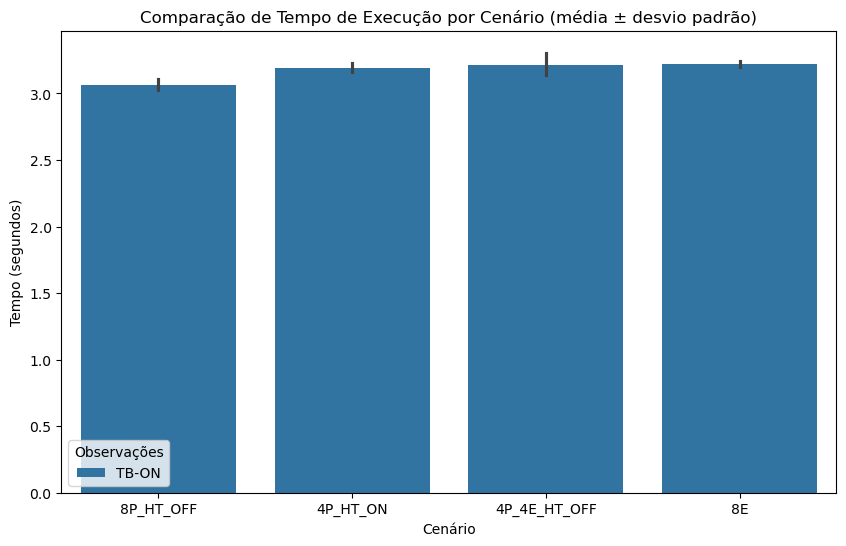

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Supondo que seus arquivos estejam em CSV
df1 = pd.read_csv('experimentos02-dask/20251121_173654_matrix6000_numruns10_performance.csv') # Com Turbo Bost
#df2 = pd.read_csv('20251111_170848_matrix1000_numruns5_performance.csv') 

df1['Dataset'] = 'TB-ON'
#df2['Dataset'] = '-'

#df_combined = pd.concat([df1, df2], ignore_index=True)

plt.figure(figsize=(10,6))
#sns.barplot(x='Scenario', y='Time_sec', hue='Dataset', data=df_combined, ci='sd')
sns.barplot(
    x='Scenario',
    y='Time_sec',
    hue='Dataset',
    data=df1,
    estimator='mean'       # calcula a média automaticamente
    #errorbar='sd'           # mostra desvio padrão
)
plt.title('Comparação de Tempo de Execução por Cenário (média ± desvio padrão)')
plt.ylabel('Tempo (segundos)')
plt.xlabel('Cenário')
plt.legend(title='Observações')

# Salvar como PDF
#plt.savefig('grafico_time_sec.pdf', format='pdf', bbox_inches='tight')

# Salvar como PNG
plt.savefig('grafico_time_sec.png', format='png', dpi=300, bbox_inches='tight')

plt.show()

In [8]:
import psutil
import getpass
import os
import sys
import time
import numpy as np
import pandas as pd
from datetime import datetime
from dask.distributed import Client, LocalCluster

# Força TODAS as bibliotecas numéricas a serem single-thread
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

# --------------------------------------
# CONFIGURATION
MATRIX_SIZE = 6000
CPU_SETS = {   
    "8P_HT_OFF": [0, 2, 4, 6, 8, 10, 12, 14], # p-cores (8 cores, 1 thread per core)
    "4P_HT_ON": [0, 1, 2, 3, 4, 5, 6, 7], # p-cores (4 cores, 2 threads per core)
    "4P_4E_HT_OFF": [0, 2, 4, 6, 16, 17, 18, 19], # p-cores e e-cores (4 cores p-core, 4 cores e-core)
    "8E": [16, 17, 18, 19, 20, 21, 22, 23] # e-cores (8 cores, 1 thread per core)
}
NUM_RUNS = 10
GOVERNOR = "performance"
IDLE_TIME = 15

# --------------------------------------
# Helper Functions (Governor & Safety)
def safety_check(cpu_ids):
    if MATRIX_SIZE % len(cpu_ids) != 0:
        print(f"Error: MATRIX_SIZE ({MATRIX_SIZE}) not divisible by workers ({len(cpu_ids)}).")
        sys.exit(1)

def set_governor(governor: str):
    """
    Altera o CPU governor de todos os núcleos para o valor especificado.

    Parâmetros:
        governor (str): nome do governor (ex.: "performance", "powersave", "schedutil").
    """
    password = getpass.getpass("Sudo password: ")

    # Interpolamos o valor do parâmetro governor dirTempetamente no comando bash
    bash_command = f"""
    for cpu_file in $(ls -v /sys/devices/system/cpu/cpu*/cpufreq/scaling_governor); do
        cpu_name=$(basename $(dirname $(dirname $cpu_file)))
        
        echo "{governor}" | sudo tee $cpu_file > /dev/null
        
        current_gov=$(cat $cpu_file)
        #echo "$cpu_name: $current_gov"
    done
    """

    # Usa sudo -S para aceitar senha via stdin
    command = f'echo "{password}" | sudo -S bash -c \'{bash_command}\''
    os.system(command)   

def get_governor(cpu_id):
    path = f"/sys/devices/system/cpu/cpu{cpu_id}/cpufreq/scaling_governor"
    try:
        with open(path) as f: return f.read().strip()
    except FileNotFoundError: return "N/A"

# --------------------------------------

def worker_task_dask(args):
    # Ignoramos as matrizes A e B grandes para não gargalar a RAM
    row_index, chunk_size, cpu_ids, _, _ = args 
    
    # --- Configuração de Afinidade ---
    worker_id = row_index // chunk_size 
    target_cpu = cpu_ids[worker_id % len(cpu_ids)]
    p = psutil.Process(os.getpid())
    p.cpu_affinity([target_cpu])
    
    # --- Carga de Trabalho SINTÉTICA (CPU Bound) ---
    # Criamos uma matriz PEQUENA (1000x1000 de double são 8MB, cabe no Cache L2/L3)
    # Isso isola o teste da velocidade da memória RAM
    local_matrix = np.random.rand(1000, 1000)
    
    # Loop de estresse matemático puro
    # Aumente o range se estiver muito rápido (< 10s)
    # P-cores devem "triturar" isso muito mais rápido que E-cores
    res = local_matrix
    for _ in range(200): 
        # Seno e Cosseno são computacionalmente caros e dependem de clock puro
        res = np.sin(res) + np.cos(res)
        
    # Retorna um número simples para evitar tráfego de rede/processo
    return np.sum(res)

# --------------------------------------
# Main Execution
if __name__ == "__main__":
    # print("Passo 1: Configurar governor")
    set_governor(GOVERNOR) # Descomente se tiver permissões sudo

    results = []
    print("Passo 2: Execuções com Dask")

    # Gerar dados
    A_host = np.random.rand(MATRIX_SIZE, MATRIX_SIZE).astype(np.float64)
    B_host = np.random.rand(MATRIX_SIZE, MATRIX_SIZE).astype(np.float64)
    
    for run in range(1, NUM_RUNS + 1):
        for label, cores in CPU_SETS.items():
            safety_check(cores)
            governor = get_governor(cores[0])            

            chunk_size = MATRIX_SIZE // len(cores)

            # -------------------------------------------------------
            # INÍCIO DO BLOCO DASK
            # Criamos um cluster local efêmero para simular o Pool
            # threads_per_worker=1 garante que é multiprocesso puro, não multithread
            # -------------------------------------------------------
            with LocalCluster(n_workers=len(cores), 
                              threads_per_worker=1, 
                              processes=True,
                              silence_logs=40) as cluster:
                
                with Client(cluster) as client:
                    # 1. SCATTER: Enviar dados para a memória comparitlhada dos workers
                    # Isso substitui a herança de memória global do fork()
                    # broadcast=True envia para todos os workers antecipadamente

                    # 2. PREPARAR TASKS
                    # Passamos os futures (A_future, B_future) ao invés dos dados crus
                    tasks_args = []
                    for i in range(len(cores)):
                        args = (i * chunk_size, chunk_size, cores, None, None)
                        tasks_args.append(args)

                    start_time = time.time()     
                        
                    # 3. SUBMIT & GATHER
                    # map envia as tarefas e retorna futures
                    futures = client.map(worker_task_dask, tasks_args)
                    
                    # gather bloqueia até terminar e traz os resultados
                    C_chunks = client.gather(futures)
                    
                    # 4. COMBINAR
                    C = np.vstack(C_chunks)
                    
                    end_time = time.time()
            # -------------------------------------------------------

            total_time = end_time - start_time
            
            # Validação de resultados
            #C_reference = np.matmul(A_host, B_host)
            #is_match = np.allclose(C, C_reference)
            #validacao_ok = "OK" if is_match else "FAIL"
            #print(f"  -> Validação: {validacao_ok}")
            
            results.append({
                "Run": run, "Scenario": label, "CPUs_used": cores,
                "Governor": governor, "Time_sec": total_time, "Result_shape": C.shape
            })
            print(f"Run {run} | Time: {total_time:.4f}s | {label}: {cores}")
            time.sleep(IDLE_TIME)

    df_results = pd.DataFrame(results)
    print("\nResumo Dask:\n", df_results[["Run", "Scenario", "Time_sec"]].sort_values(by="Scenario"))
    
    # cria dataframe com todos os resultados
    df_results = pd.DataFrame(results)
    pd.set_option('display.width', 1000) # Evita quebra de linha do print do df  
    df_reduced = df_results[["Run", "Scenario", "Governor", "Time_sec"]]
    df_sorted = df_reduced.sort_values(by="Scenario", ascending=False)
    print("\nResumo em DataFrame:\n", df_sorted)
    
    # salvar em CSV
    now = datetime.now()
    data_str = now.strftime("%Y%m%d") # formato aaaammdd
    hora_str = now.strftime("%H%M%S") # formato hhmmss
    filename = (
    f"experimentos02-dask/{data_str}_{hora_str}_matrix{MATRIX_SIZE}_"
        f"numruns{NUM_RUNS}_{GOVERNOR}.csv"
    )
    df_results.to_csv(filename, index=False)
    print(f"\nResultados salvos em: {filename}") 
    
    

Sudo password: ········


[sudo] senha para jgross: 

Passo 2: Execuções com Dask
Run 1 | Time: 3.1469s | 8P_HT_OFF: [0, 2, 4, 6, 8, 10, 12, 14]
Run 1 | Time: 3.1660s | 4P_HT_ON: [0, 1, 2, 3, 4, 5, 6, 7]
Run 1 | Time: 3.1408s | 4P_4E_HT_OFF: [0, 2, 4, 6, 16, 17, 18, 19]
Run 1 | Time: 3.1949s | 8E: [16, 17, 18, 19, 20, 21, 22, 23]
Run 2 | Time: 3.0525s | 8P_HT_OFF: [0, 2, 4, 6, 8, 10, 12, 14]
Run 2 | Time: 3.1520s | 4P_HT_ON: [0, 1, 2, 3, 4, 5, 6, 7]
Run 2 | Time: 3.1306s | 4P_4E_HT_OFF: [0, 2, 4, 6, 16, 17, 18, 19]
Run 2 | Time: 3.2112s | 8E: [16, 17, 18, 19, 20, 21, 22, 23]
Run 3 | Time: 3.2212s | 8P_HT_OFF: [0, 2, 4, 6, 8, 10, 12, 14]
Run 3 | Time: 3.1676s | 4P_HT_ON: [0, 1, 2, 3, 4, 5, 6, 7]
Run 3 | Time: 3.1568s | 4P_4E_HT_OFF: [0, 2, 4, 6, 16, 17, 18, 19]
Run 3 | Time: 3.1965s | 8E: [16, 17, 18, 19, 20, 21, 22, 23]
Run 4 | Time: 3.0103s | 8P_HT_OFF: [0, 2, 4, 6, 8, 10, 12, 14]
Run 4 | Time: 3.1859s | 4P_HT_ON: [0, 1, 2, 3, 4, 5, 6, 7]
Run 4 | Time: 3.0845s | 4P_4E_HT_OFF: [0, 2, 4, 6, 16, 17, 18, 19]
Run 4 | Time: 3.3226s | 8E: [16, 